In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# import from package 'geone'
from geone import img
import geone.imgplot as imgplt
import geone.customcolors as ccol
import geone.deesseinterface as dsi

import pickle
import time

In [44]:
path_generated = 'generated_data'
data_name = 'realisation8.pickle'

In [45]:
import os
os.listdir(path_generated)

['realisation0.pickle',
 'realisation1.pickle',
 'realisation2.pickle',
 'realisation3.pickle',
 'realisation4.pickle',
 'realisation5.pickle',
 'realisation6.pickle',
 'realisation7.pickle',
 'realisation8.pickle',
 'realisation9.pickle']

In [46]:
exec(open('functions/04_function.py').read())

In [5]:
trueMNT, position, hd_df, ti= read_data(path_generated,data_name)

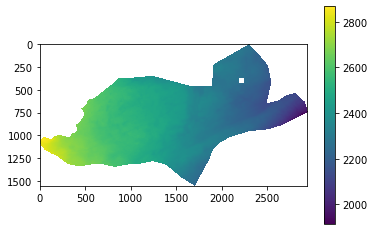

In [6]:
ti[ti == np.min(np.min(ti)) ] = np.nan
plt.imshow(ti)
 
plt.colorbar()

In [15]:
hd_df

,cell_x,cell_y,alt,X,Y
0,2167,395,2280.284180,584078.0,135556.0
1,2167,396,2280.264893,584080.0,135556.0
2,2167,397,2280.304932,584082.0,135556.0
3,2167,398,2280.402832,584084.0,135556.0
4,2167,399,2280.601318,584086.0,135556.0
...,...,...,...,...,...
457,2241,439,2247.350342,584166.0,135704.0
458,2241,440,2245.443359,584168.0,135704.0
459,2241,441,2244.259277,584170.0,135704.0
460,2241,442,2243.448975,584172.0,135704.0


In [14]:
plt.imshow(extra[0])

NameError: name 'extra' is not defined

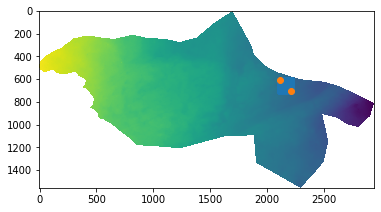

In [26]:
plt.imshow(simu[0].val[0,0,:,:])
plt.scatter(hd_pts.x(),hd_pts.y())
plt.scatter([position[0],position[1]],[position[2],position[3]])


(1, 1, 1555, 2943)


C:\Users\nevena\AppData\Local\Continuum\anaconda3\envs\Pyclass36\lib\site-packages\ipykernel_launcher.py:117: RuntimeWarning: invalid value encountered in less


********************************************************************************
DEESSE VERSION 3.2 / BUILD NUMBER 20200213
********************************************************************************
DONE


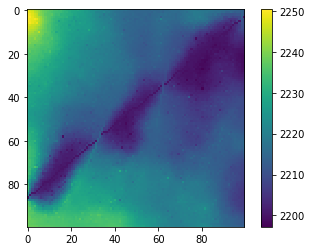

In [28]:
#Simu zone + TI  OK
#ti = np.flipud(ti)
mask_ti = create_mask_ti('ti_alt2_alti3d.pickle')
hd_pts  = create_hd(hd_df,ti.shape[0],sx=1,sy=1)
#hd_pts.val[1] = 1555-hd_pts.val[1]
ti_img  = create_ti(ti)
simu    = deeSse_run_ti(ti_img,mask_ti,hd_pts=hd_pts,t=0.5)
extra   = extract_simu_zone(simu,position)
plt.imshow(extra[0])
plt.colorbar()

In [47]:
    #Simu1 zone + TI  
    mask_ti = create_mask_ti('ti_alt2_alti3d.pickle')
    hd_pts  = create_hd(hd_df)
    ti_img  = create_ti(ti)
    mask_zone = create_mask_zone('ti_alt2_alti3d.pickle',position)

    simu4   = deeSse_run_zone_pyr(ti_img, mask_zone, hd_pts,n=12, t=0.2, f=0.5, nReal = 5)

    #Simu2 zone + TI + Pyramide
    simu2   = deeSse_run_ti_pyr(ti_img, mask_ti, hd_pts, n=12, t=0.2, f=0.5, nReal = 5)
    extr2   = extract_simu_zone(simu2,position)
    extr4   = extract_simu_zone(simu4,position)

(1, 1, 1555, 2943)
********************************************************************************

C:\Users\nevena\AppData\Local\Continuum\anaconda3\envs\Pyclass36\lib\site-packages\ipykernel_launcher.py:117: RuntimeWarning: invalid value encountered in less



DEESSE VERSION 3.2 / BUILD NUMBER 20200213
********************************************************************************
DONE
********************************************************************************
DEESSE VERSION 3.2 / BUILD NUMBER 20200213
********************************************************************************
DONE


In [ ]:
#Simu zone + TI  OK
#ti = np.flipud(ti)
mask_ti = create_mask_ti('ti_alt2_alti3d.pickle')
hd_pts  = create_hd(hd_df,ti.shape[0],sx=1,sy=1)
ti_img  = create_ti(ti)
simu    = deeSse_run_ti(ti_img,mask_ti)
extra   = extract_simu_zone(simu,position)
plt.imshow(extra[0])
plt.colorbar()

In [ ]:
plt.imshow(trueMNT)
plt.colorbar()


In [ ]:
plt.plot(hd_pts.x(), hd_pts.y(), '+', markersize=1, c='red') # add hard data points
plt.imshow((simu[0].val[0,0]), cmap=ccol.cmapB2W) # plot real #i
essai = np.flipud(simu[0].val[0,0])

In [ ]:
extra

In [ ]:
plt.plot(hd_pts.x(), hd_pts.y(), '+', markersize=1, c='red') # add hard data points
plt.imshow((extra[0])) # plot real #i

In [ ]:
plt.plot(hd_pts.x(), hd_pts.y(), '+', markersize=1, c='red') # add hard data points
plt.imshow(ti_img.val[0,0], cmap=ccol.cmapB2W) # plot real #i

In [ ]:
plt.imshow(essai)
position

In [ ]:
plt.imshow((ti_img.val[0,0]))
#plt.scatter(hd_df['cell_x'],hd_df['cell_y'])
#plt.scatter(0,0)
plt.scatter(hd_pts.x(),hd_pts.y())


In [ ]:
#Simu zone + TI + Pyramide OK
mask_ti = create_mask_ti('ti_alt1_alti3d.pickle')
hd_pts  = create_hd(hd_df)
ti_img  = create_ti(ti)
simu    = deeSse_run_ti_pyr(ti_img,mask_ti,hd_pts)
extra   = extract_simu_zone(simu,position)
plt.imshow(extra[0])

In [ ]:
#Simu zone OK
mask_zone = create_mask_zone('ti_alt1_alti3d.pickle',position)
hd_pts  = create_hd(hd_df)
ti_img  = create_ti(ti)
simu    = deeSse_run_zone(ti_img, mask_zone, hd_pts)
extra   = extract_simu_zone(simu,position)
plt.imshow(extra[0])

In [ ]:
#Simu zone +pyramide OK
mask_zone = create_mask_zone('ti_alt1_alti3d.pickle',position)
hd_pts  = create_hd(hd_df)
ti_img  = create_ti(ti)
simu    = deeSse_run_zone_pyr(ti_img, mask_zone, hd_pts)
extra   = extract_simu_zone(simu,position)
plt.imshow(extra[0])

In [ ]:
plt.imshow(trueMNT)

In [ ]:
plt.imshow((ti_img.val[0,0])-(simu[0].val[0,0]))


In [16]:
dimension, spacing, origin = create_grid(position)


In [19]:
origin

[2167.0, 369.0]

In [20]:
position

[2167, 2242, 369, 444]

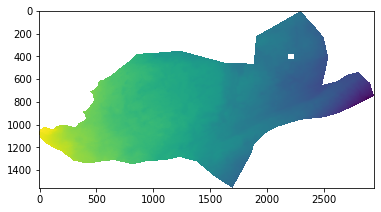

In [48]:
plt.imshow(ti_img.val[0,0])

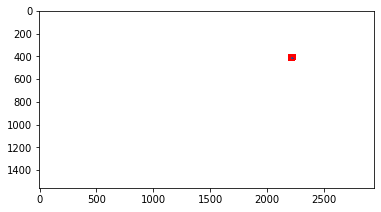

In [49]:
plt.imshow(simu4[0].val[0,0])
plt.plot(hd_pts.x(), hd_pts.y(), '+', markersize=1, c='red') # add hard data points


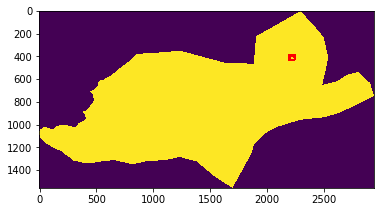

In [50]:
plt.imshow(mask_ti.val[0,0])
plt.plot(hd_pts.x(), hd_pts.y(), '+', markersize=1, c='red') # add hard data points


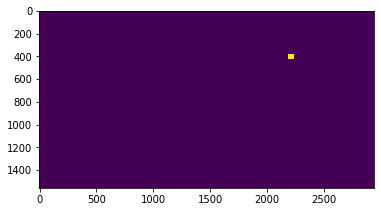

In [51]:
plt.imshow(mask_zone.val[0,0])

In [52]:
extr2[0]

array([[2276.61348922, 2276.68085395, 2276.79063421, ..., 2259.39781241,
        2259.25219727, 2259.35975477],
       [2276.67865668, 2276.9449056 , 2277.02724406, ..., 2259.6232242 ,
        2258.95605469, 2258.81095378],
       [2276.18774414, 2276.7945912 , 2277.17223494, ..., 2258.75911458,
        2258.70117188, 2258.69772678],
       ...,
       [2262.23730469, 2261.78881836, 2261.76733398, ..., 2254.65953234,
        2254.90893555, 2255.15595161],
       [2262.12060547, 2261.82641602, 2261.49975586, ..., 2254.51855469,
        2254.60571289, 2255.01424154],
       [2262.42876519, 2261.98844401, 2261.42602539, ..., 2254.22843424,
        2254.3078342 , 2254.32209382]])

In [39]:
position

[2186, 2236, 376, 426]

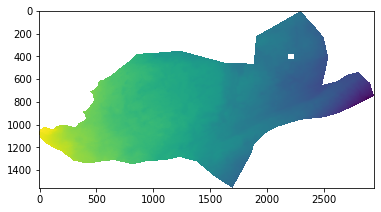

In [53]:
plt.imshow(ti_img.val[0,0])

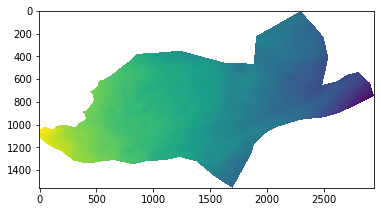

In [55]:
plt.imshow(simu2[0].val[0,0])

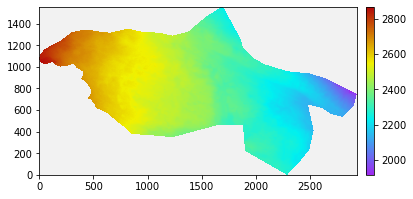

In [57]:
imgplt.drawImage2D(simu2[0])